# 04 — ECG Signal Forecasting: Modelling Pipeline
**PTB-XL 12-Lead ECG — Frankfurt University of Applied Sciences · HIS Masters Project**

| | |
|---|---|
| **Task** | **Multivariate Time Series Forecasting** (regression, not classification) |
| **Input** | X_in ∈ ℝ^(500 × 12) — 5 seconds of past ECG across all 12 leads |
| **Target** | y_fore ∈ ℝ^(100 × 12) — next 1 second of ECG signal values in mV |
| **Loss** | Huber Loss — smooth, robust to mV outliers |
| **Metrics** | MAE · RMSE · MAPE per lead and macro-averaged |
| **Models** | LSTM → CNN-LSTM → Transformer |
| **Data** | Loaded from `data/processed/` (output of `02_preprocessing_forecasting.ipynb`) |

### Why forecasting?
This is a **regression** problem: the model outputs continuous mV values, not class labels.
A correct prediction looks like a realistic ECG waveform 1 second into the future.
This enables ICU real-time anomaly detection, wearable signal reconstruction, and
early arrhythmia warning when forecasting error suddenly spikes.

### Pipeline
```
data/processed/   X_train (N,500,12)  y_train (N,100,12)
        ↓
    PyTorch Dataset + DataLoaders
        ↓
    Model A: LSTM Forecaster          — bidirectional, attention pooling
    Model B: CNN-LSTM Forecaster      — CNN local features + LSTM temporal
    Model C: Transformer Forecaster   — self-attention, full sequence context
        ↓
    Training: HuberLoss + AdamW + CosineAnnealingLR + early stopping
        ↓
    Evaluation: MAE · RMSE · MAPE per lead + macro
        ↓
    Visualisation: predicted vs actual · loss curves · per-lead error bars
        ↓
    Literature comparison
```

### Cell 1 — Install & Import

In [4]:
# ============================================================
# CELL 1: INSTALL & IMPORT
# ============================================================
!pip install torch torchvision scikit-learn matplotlib numpy tqdm --quiet

import os, pickle, time, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── Reproducibility ───────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print("\n✅ All imports ready")

PyTorch  : 2.11.0
Device   : cpu

✅ All imports ready


### Cell 2 — Load Processed Data

In [5]:
# ============================================================
# CELL 2: LOAD PROCESSED DATA FROM 02_PREPROCESSING
# ============================================================

SAVE_DIR = os.path.join('..', 'data', 'processed')
FIG_DIR  = os.path.join('..', 'reports', 'figures')
CKPT_DIR = os.path.join('..', 'reports', 'checkpoints')
os.makedirs(FIG_DIR,  exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

X_train = np.load(os.path.join(SAVE_DIR, 'X_train.npy'))  # (N, 500, 12)
y_train = np.load(os.path.join(SAVE_DIR, 'y_train.npy'))  # (N, 100, 12) ← signal, not labels
X_val   = np.load(os.path.join(SAVE_DIR, 'X_val.npy'))
y_val   = np.load(os.path.join(SAVE_DIR, 'y_val.npy'))
X_test  = np.load(os.path.join(SAVE_DIR, 'X_test.npy'))
y_test  = np.load(os.path.join(SAVE_DIR, 'y_test.npy'))

with open(os.path.join(SAVE_DIR, 'config.pkl'), 'rb') as f:
    cfg = pickle.load(f)

LEAD_NAMES = cfg['lead_names']
FS         = cfg['sampling_rate']
INPUT_LEN  = cfg['input_len']      # 500
HORIZON    = cfg['horizon']        # 100
N_LEADS    = cfg['n_leads']        # 12

print("=" * 60)
print("  DATA LOADED")
print("=" * 60)
print(f"  Task        : {cfg['task']}  |  target: {cfg['target_type']}")
print(f"  X_train     : {X_train.shape}   y_train : {y_train.shape}")
print(f"  X_val       : {X_val.shape}    y_val   : {y_val.shape}")
print(f"  X_test      : {X_test.shape}    y_test  : {y_test.shape}")
print(f"  Input window: {INPUT_LEN} samples = {INPUT_LEN/FS:.0f}s")
print(f"  Horizon     : {HORIZON} samples = {HORIZON/FS:.0f}s")
print(f"  Device      : {DEVICE}")
print()

# ── Assert this is forecasting data, not classification ───────
assert y_train.ndim == 3, "y_train must be (N, HORIZON, 12) — 3D signal array"
assert y_train.shape[1] == HORIZON
assert y_train.shape[2] == N_LEADS
assert y_train.dtype == np.float32

print("✅ Data verified: y_train is continuous signal (not class labels)")
print(f"   y_train value range: [{y_train.min():.3f}, {y_train.max():.3f}] mV")

  DATA LOADED
  Task        : forecasting  |  target: continuous_signal_mV
  X_train     : (635, 500, 12)   y_train : (635, 100, 12)
  X_val       : (210, 500, 12)    y_val   : (210, 100, 12)
  X_test      : (155, 500, 12)    y_test  : (155, 100, 12)
  Input window: 500 samples = 5s
  Horizon     : 100 samples = 1s
  Device      : cpu

✅ Data verified: y_train is continuous signal (not class labels)
   y_train value range: [-8.344, 11.073] mV


### Cell 3 — PyTorch Dataset & DataLoaders

In [6]:
# ============================================================
# CELL 3: PYTORCH DATASET & DATALOADERS
#
# ECGForecastDataset returns:
#   x : (INPUT_LEN, 12)  or  (12, INPUT_LEN)  — encoder input
#   y : (HORIZON, 12)                          — regression target (mV)
#
# Both x and y are continuous float32 tensors — no class labels.
# ============================================================

class ECGForecastDataset(Dataset):
    """
    PyTorch Dataset for PTB-XL multivariate ECG forecasting.

    x → past signal window   (INPUT_LEN, 12)
    y → future signal window (HORIZON, 12)     ← continuous mV regression target
    """
    def __init__(self, X, y, channel_first=False):
        self.X            = torch.from_numpy(X)   # float32
        self.y            = torch.from_numpy(y)   # float32
        self.channel_first = channel_first

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]    # (500, 12)
        y = self.y[idx]    # (100, 12)
        if self.channel_first:
            x = x.permute(1, 0)   # → (12, 500) for CNN
        return x, y


def make_loaders(X_tr, y_tr, X_v, y_v, X_te, y_te,
                 channel_first=False, batch_train=64, batch_eval=128):
    # num_workers=0 is required in Jupyter notebooks on macOS/Windows.
    # PyTorch multiprocessing (spawn) cannot pickle classes defined in
    # notebook cells. num_workers=0 runs data loading in the main process.
    # On a Linux server or Colab, you can safely set num_workers=4.
    n_cpu = 0
    pin   = (DEVICE.type == 'cuda') and (n_cpu > 0)
    kw    = dict(num_workers=n_cpu, pin_memory=pin)

    tr = DataLoader(ECGForecastDataset(X_tr, y_tr, channel_first),
                    batch_size=batch_train, shuffle=True, drop_last=True, **kw)
    vl = DataLoader(ECGForecastDataset(X_v,  y_v,  channel_first),
                    batch_size=batch_eval,  shuffle=False, **kw)
    te = DataLoader(ECGForecastDataset(X_te, y_te, channel_first),
                    batch_size=batch_eval,  shuffle=False, **kw)
    return tr, vl, te

# Time-first loaders → (B, 500, 12)  for LSTM and Transformer
lstm_tr, lstm_vl, lstm_te = make_loaders(
    X_train, y_train, X_val, y_val, X_test, y_test, channel_first=False)

# Channel-first loaders → (B, 12, 500)  for CNN-LSTM
cnn_tr, cnn_vl, cnn_te = make_loaders(
    X_train, y_train, X_val, y_val, X_test, y_test, channel_first=True)

xb, yb = next(iter(lstm_tr))
print(f"LSTM batch    : x={xb.shape}  y={yb.shape}  dtype={xb.dtype}")
xb2, _ = next(iter(cnn_tr))
print(f"CNN-LSTM batch: x={xb2.shape}")
print(f"\nTrain batches: {len(lstm_tr)} | Val: {len(lstm_vl)} | Test: {len(lstm_te)}")
print("\n✅ DataLoaders ready — targets are continuous signal tensors")

LSTM batch    : x=torch.Size([64, 500, 12])  y=torch.Size([64, 100, 12])  dtype=torch.float32
CNN-LSTM batch: x=torch.Size([64, 12, 500])

Train batches: 9 | Val: 2 | Test: 2

✅ DataLoaders ready — targets are continuous signal tensors


### Cell 4 — Model A: LSTM Forecaster

```
Input  (B, 500, 12)
   ↓  Bidirectional LSTM  hidden=128 × 2 layers  dropout=0.2
   ↓  Temporal attention pooling over 500 timesteps → (B, 256)
   ↓  Linear(256→256)  GELU  Linear(256→100×12)
Output (B, 100, 12)  — predicted mV values
```

In [7]:
# ============================================================
# CELL 4: MODEL A — LSTM FORECASTER
# ============================================================

class LSTMForecaster(nn.Module):
    """
    Bidirectional LSTM with temporal attention for multivariate
    ECG signal forecasting.

    Bidirectionality doubles the hidden state at each timestep by
    processing the input sequence in both forward and backward directions,
    allowing the encoder to capture both causal and anti-causal temporal
    dependencies within the input window.

    Temporal attention replaces the naive final-state readout with a
    learned soft weighting over all 500 timesteps, focusing the decoder
    on clinically informative regions (e.g. the QRS complex).

    Input  : (B, 500, 12)
    Output : (B, 100, 12)  — continuous mV forecast
    """

    def __init__(self, n_leads=12, hidden=128, n_layers=2,
                 dropout=0.2, horizon=100, bidirectional=True):
        super().__init__()
        self.horizon = horizon
        self.n_leads = n_leads
        self.D       = 2 if bidirectional else 1

        self.lstm = nn.LSTM(
            input_size    = n_leads,
            hidden_size   = hidden,
            num_layers    = n_layers,
            batch_first   = True,
            dropout       = dropout if n_layers > 1 else 0.0,
            bidirectional = bidirectional,
        )

        self.attn = nn.Sequential(
            nn.Linear(hidden * self.D, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
        )

        self.decoder = nn.Sequential(
            nn.LayerNorm(hidden * self.D),
            nn.Dropout(dropout),
            nn.Linear(hidden * self.D, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, horizon * n_leads),
        )

    def forward(self, x):
        enc, _  = self.lstm(x)                          # (B, 500, hidden*D)
        w       = torch.softmax(self.attn(enc), dim=1)  # (B, 500, 1)
        ctx     = (w * enc).sum(dim=1)                  # (B, hidden*D)
        out     = self.decoder(ctx)                      # (B, horizon*leads)
        return out.view(-1, self.horizon, self.n_leads)  # (B, 100, 12)


lstm_model = LSTMForecaster(
    n_leads=N_LEADS, hidden=128, n_layers=2,
    dropout=0.2, horizon=HORIZON, bidirectional=True
).to(DEVICE)

n_lstm = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)

with torch.no_grad():
    d = torch.randn(4, INPUT_LEN, N_LEADS).to(DEVICE)
    o = lstm_model(d)
    print(f"LSTM   : {d.shape} → {o.shape}  ✅")
print(f"Params : {n_lstm:,}")

LSTM   : torch.Size([4, 500, 12]) → torch.Size([4, 100, 12])  ✅
Params : 931,889


### Cell 5 — Model B: CNN-LSTM Forecaster

```
Input  (B, 12, 500)          channel-first
   ↓  Conv1d blocks: 500 → 250 → 125 → 62 timesteps
   ↓  permute → (B, 62, 128)
   ↓  Bidirectional LSTM hidden=128 × 2 layers
   ↓  Attention pooling → (B, 256)
   ↓  Linear(256→100×12)
Output (B, 100, 12)
```

In [8]:
# ============================================================
# CELL 5: MODEL B — CNN-LSTM FORECASTER
# ============================================================

class ConvBlock(nn.Module):
    """Conv1d → BatchNorm1d → GELU → optional MaxPool2."""
    def __init__(self, in_ch, out_ch, k, pool=True):
        super().__init__()
        ops = [
            nn.Conv1d(in_ch, out_ch, kernel_size=k,
                      padding=k//2, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
        ]
        if pool:
            ops.append(nn.MaxPool1d(2))
        self.net = nn.Sequential(*ops)

    def forward(self, x):
        return self.net(x)


class CNNLSTMForecaster(nn.Module):
    """
    CNN-LSTM hybrid for multivariate ECG forecasting.

    The CNN extracts local morphological features (QRS shape,
    P-wave onset, T-wave morphology) at multiple temporal scales
    via learned 1-D filters, compressing 500 → 62 timesteps.
    This reduces the sequence length fed to the LSTM by 8×,
    improving gradient flow and training efficiency while
    preserving the most discriminative signal features.

    Input  : (B, 12, 500)  channel-first
    Output : (B, 100, 12)  continuous mV forecast
    """

    def __init__(self, n_leads=12, horizon=100, dropout=0.2,
                 lstm_hidden=128, bidirectional=True):
        super().__init__()
        self.horizon = horizon
        self.n_leads = n_leads
        self.D       = 2 if bidirectional else 1

        # 500 → 250 → 125 → 62
        self.cnn = nn.Sequential(
            ConvBlock(n_leads, 32,  k=7, pool=True),
            ConvBlock(32,      64,  k=5, pool=True),
            ConvBlock(64,      128, k=3, pool=True),
            ConvBlock(128,     128, k=3, pool=False),
        )

        self.lstm = nn.LSTM(
            input_size    = 128,
            hidden_size   = lstm_hidden,
            num_layers    = 2,
            batch_first   = True,
            dropout       = dropout,
            bidirectional = bidirectional,
        )

        self.attn = nn.Sequential(
            nn.Linear(lstm_hidden * self.D, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
        )

        self.decoder = nn.Sequential(
            nn.LayerNorm(lstm_hidden * self.D),
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden * self.D, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, horizon * n_leads),
        )

    def forward(self, x):
        f   = self.cnn(x).permute(0, 2, 1)              # (B, 62, 128)
        enc, _ = self.lstm(f)                            # (B, 62, hidden*D)
        w   = torch.softmax(self.attn(enc), dim=1)       # (B, 62, 1)
        ctx = (w * enc).sum(dim=1)                       # (B, hidden*D)
        out = self.decoder(ctx)
        return out.view(-1, self.horizon, self.n_leads)  # (B, 100, 12)


cnn_lstm_model = CNNLSTMForecaster(
    n_leads=N_LEADS, horizon=HORIZON, dropout=0.2,
    lstm_hidden=128, bidirectional=True
).to(DEVICE)

n_cnn = sum(p.numel() for p in cnn_lstm_model.parameters() if p.requires_grad)

with torch.no_grad():
    d = torch.randn(4, N_LEADS, INPUT_LEN).to(DEVICE)
    o = cnn_lstm_model(d)
    print(f"CNN-LSTM: {d.shape} → {o.shape}  ✅")
print(f"Params  : {n_cnn:,}")

CNN-LSTM: torch.Size([4, 12, 500]) → torch.Size([4, 100, 12])  ✅
Params  : 1,138,033


### Cell 6 — Model C: Transformer Forecaster

```
Input  (B, 500, 12)
   ↓  Linear projection → d_model=128
   ↓  Sinusoidal positional encoding
   ↓  Transformer Encoder — 4 layers, 8 heads, d_ff=256, pre-LN
   ↓  Mean pooling → (B, 128)
   ↓  Linear(128→100×12)
Output (B, 100, 12)
```

Self-attention allows every timestep to attend to every other — capturing
long-range ECG dependencies (P→QRS→T relationships) that LSTMs may lose
over 500 steps of sequential processing.

In [9]:
# ============================================================
# CELL 6: MODEL C — TRANSFORMER FORECASTER
# ============================================================

class SinusoidalPE(nn.Module):
    """
    Fixed sinusoidal positional encoding (Vaswani et al. 2017).
    Injects temporal order since Transformer has no sequence notion.
      PE(t, 2i)   = sin(t / 10000^(2i/d_model))
      PE(t, 2i+1) = cos(t / 10000^(2i/d_model))
    """
    def __init__(self, d_model, max_len=600, dropout=0.1):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return self.drop(x + self.pe[:, :x.size(1)])


class TransformerForecaster(nn.Module):
    """
    Transformer encoder for multivariate ECG forecasting.

    Scaled dot-product multi-head attention:
        Attention(Q,K,V) = softmax(QK^T / sqrt(d_k)) V

    Pre-Layer-Norm (norm_first=True) placement stabilises training
    compared to the original post-LN formulation, especially important
    for time series regression where output scale matters.

    Input  : (B, 500, 12)
    Output : (B, 100, 12)  continuous mV forecast
    """

    def __init__(self, n_leads=12, d_model=128, nhead=8,
                 num_layers=4, d_ff=256, dropout=0.1, horizon=100):
        super().__init__()
        self.horizon = horizon
        self.n_leads = n_leads

        self.input_proj = nn.Linear(n_leads, d_model)
        self.pos_enc    = SinusoidalPE(d_model, max_len=600, dropout=dropout)

        enc_layer = nn.TransformerEncoderLayer(
            d_model         = d_model,
            nhead           = nhead,
            dim_feedforward = d_ff,
            dropout         = dropout,
            activation      = 'gelu',
            batch_first     = True,
            norm_first      = True,   # Pre-LN: more stable for regression
        )
        self.encoder = nn.TransformerEncoder(
            enc_layer, num_layers=num_layers,
            norm=nn.LayerNorm(d_model)
        )

        self.decoder = nn.Sequential(
            nn.Linear(d_model, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, horizon * n_leads),
        )

    def forward(self, x):
        x   = self.pos_enc(self.input_proj(x))  # (B, 500, d_model)
        x   = self.encoder(x)                    # (B, 500, d_model)
        ctx = x.mean(dim=1)                      # (B, d_model) — mean pool
        out = self.decoder(ctx)
        return out.view(-1, self.horizon, self.n_leads)  # (B, 100, 12)


transformer_model = TransformerForecaster(
    n_leads=N_LEADS, d_model=128, nhead=8,
    num_layers=4, d_ff=256, dropout=0.1, horizon=HORIZON
).to(DEVICE)

n_trans = sum(p.numel() for p in transformer_model.parameters() if p.requires_grad)

with torch.no_grad():
    d = torch.randn(4, INPUT_LEN, N_LEADS).to(DEVICE)
    o = transformer_model(d)
    print(f"Transformer: {d.shape} → {o.shape}  ✅")
print(f"Params     : {n_trans:,}")

print("\n" + "="*55)
print("  MODEL PARAMETER COMPARISON")
print("="*55)
print(f"  LSTM          : {n_lstm:>10,}")
print(f"  CNN-LSTM      : {n_cnn:>10,}")
print(f"  Transformer   : {n_trans:>10,}")

Transformer: torch.Size([4, 500, 12]) → torch.Size([4, 100, 12])  ✅
Params     : 873,264

  MODEL PARAMETER COMPARISON
  LSTM          :    931,889
  CNN-LSTM      :  1,138,033
  Transformer   :    873,264


### Cell 7 — Training Engine

In [10]:
# ============================================================
# CELL 7: TRAINING ENGINE
#
# Loss     : HuberLoss(delta=0.5)
#            — smooth L1, robust to large mV outlier spikes,
#              less sensitive than MSE, differentiable unlike MAE
# Optimizer: AdamW  — decoupled weight decay (better than Adam+L2)
# Scheduler: CosineAnnealingLR  — smooth LR decay, no plateau stall
# Grad clip: max_norm=1.0  — essential for LSTM stability
# Early stop: patience=12 on val loss
# ============================================================

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item() * len(xb)
    return total / len(loader.dataset)


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total = 0.0
    preds, targets = [], []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
        pred   = model(xb)
        total += criterion(pred, yb).item() * len(xb)
        preds.append(pred.cpu().numpy())
        targets.append(yb.cpu().numpy())
    loss = total / len(loader.dataset)
    return loss, np.concatenate(preds), np.concatenate(targets)


def train_model(model, tr_loader, vl_loader, model_name,
                n_epochs=60, lr=3e-4, patience=12):
    criterion = nn.HuberLoss(delta=0.5)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=lr/20)

    best_val   = float('inf')
    no_improve = 0
    ckpt       = os.path.join(CKPT_DIR, f'{model_name}_best.pt')
    history    = {'tr': [], 'vl': []}

    print(f"\n{'─'*65}")
    print(f"  Training: {model_name}")
    print(f"{'─'*65}")
    print(f"  {'Ep':>4}  {'Train Loss':>12}  {'Val Loss':>12}  {'LR':>10}  {'★':>4}")
    print(f"  {'-'*55}")

    for ep in range(1, n_epochs + 1):
        tr_loss              = train_epoch(model, tr_loader, criterion, optimizer)
        vl_loss, _, _        = eval_epoch(model, vl_loader, criterion)
        scheduler.step()

        history['tr'].append(tr_loss)
        history['vl'].append(vl_loss)

        best = vl_loss < best_val
        if best:
            best_val   = vl_loss
            no_improve = 0
            torch.save(model.state_dict(), ckpt)
        else:
            no_improve += 1

        lr_now = optimizer.param_groups[0]['lr']
        flag   = '★' if best else ''
        print(f"  {ep:>4}  {tr_loss:>12.6f}  {vl_loss:>12.6f}  {lr_now:>10.2e}  {flag}")

        if no_improve >= patience:
            print(f"\n  Early stop at epoch {ep}")
            break

    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    print(f"\n  Best val loss: {best_val:.6f}  ✅  Best checkpoint restored")
    return history


print("Training engine ready ✅")
print("  Loss      : HuberLoss(delta=0.5)")
print("  Optimizer : AdamW (lr=3e-4, wd=1e-4)")
print("  Scheduler : CosineAnnealingLR (T_max=60)")
print("  Grad clip : 1.0")
print("  Early stop: patience=12 on val loss")

Training engine ready ✅
  Loss      : HuberLoss(delta=0.5)
  Optimizer : AdamW (lr=3e-4, wd=1e-4)
  Scheduler : CosineAnnealingLR (T_max=60)
  Grad clip : 1.0
  Early stop: patience=12 on val loss


### Cell 8 — Train All Models

In [11]:
# ============================================================
# CELL 8: TRAIN ALL THREE MODELS
# ============================================================

histories = {}

# ── Model A: LSTM ─────────────────────────────────────────────
histories['LSTM'] = train_model(
    lstm_model, lstm_tr, lstm_vl,
    model_name='LSTM', n_epochs=60, lr=3e-4, patience=12
)

# ── Model B: CNN-LSTM ─────────────────────────────────────────
histories['CNN-LSTM'] = train_model(
    cnn_lstm_model, cnn_tr, cnn_vl,
    model_name='CNN-LSTM', n_epochs=60, lr=3e-4, patience=12
)

# ── Model C: Transformer ──────────────────────────────────────
histories['Transformer'] = train_model(
    transformer_model, lstm_tr, lstm_vl,
    model_name='Transformer', n_epochs=60, lr=1e-4, patience=12
)

print("\n✅ All models trained")


─────────────────────────────────────────────────────────────────
  Training: LSTM
─────────────────────────────────────────────────────────────────
    Ep    Train Loss      Val Loss          LR     ★
  -------------------------------------------------------
     1      0.205464      0.212071    3.00e-04  ★
     2      0.197062      0.210532    2.99e-04  ★
     3      0.194818      0.209315    2.98e-04  ★
     4      0.193798      0.209056    2.97e-04  ★
     5      0.192093      0.208957    2.95e-04  ★
     6      0.192146      0.208885    2.93e-04  ★
     7      0.191861      0.208658    2.91e-04  ★
     8      0.192170      0.208624    2.88e-04  ★
     9      0.191895      0.208331    2.84e-04  ★
    10      0.191258      0.207986    2.81e-04  ★
    11      0.191498      0.207843    2.77e-04  ★
    12      0.191790      0.207651    2.73e-04  ★
    13      0.191768      0.207484    2.68e-04  ★
    14      0.190919      0.207408    2.63e-04  ★
    15      0.188711      0.207303    2

### Cell 9 — Training Curves

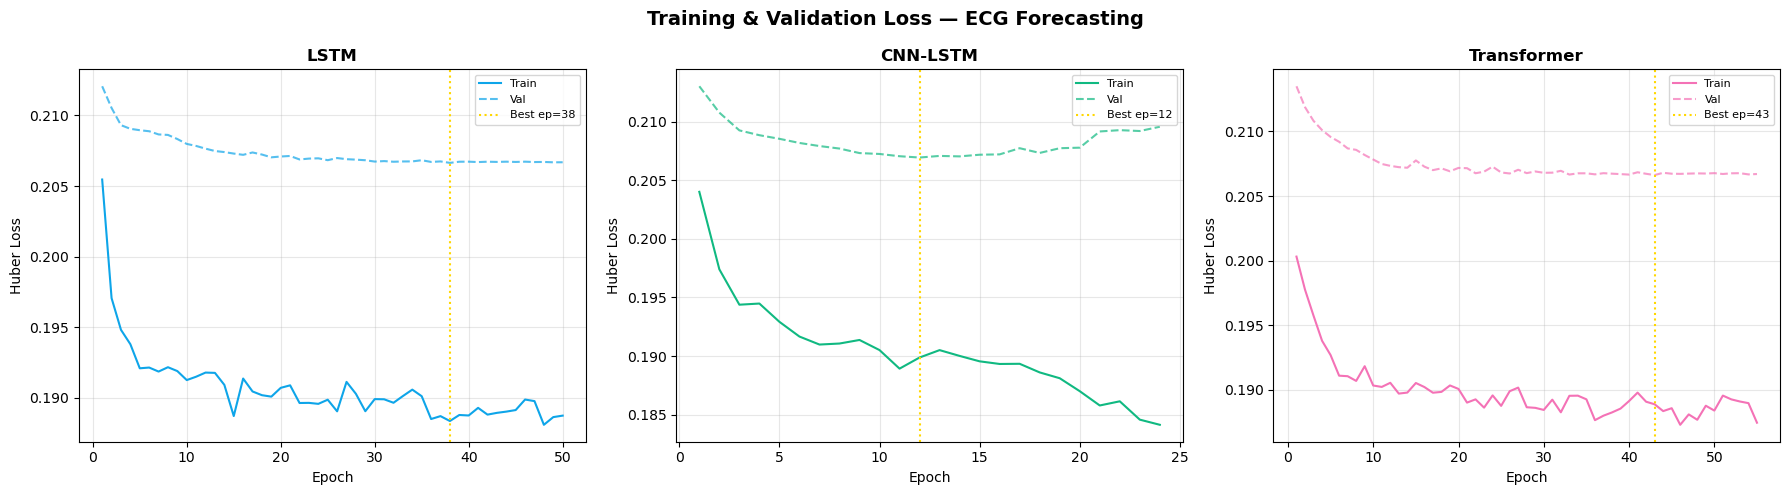

✅ Saved → reports/figures/training_loss_curves.png


In [12]:
# ============================================================
# CELL 9: TRAINING LOSS CURVES
# ============================================================

colors = {'LSTM': '#0ea5e9', 'CNN-LSTM': '#10b981', 'Transformer': '#f472b6'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, hist) in zip(axes, histories.items()):
    ep = range(1, len(hist['tr']) + 1)
    ax.plot(ep, hist['tr'], color=colors[name], lw=1.5, label='Train')
    ax.plot(ep, hist['vl'], color=colors[name], lw=1.5, ls='--', alpha=0.7, label='Val')
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Huber Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    best_ep = int(np.argmin(hist['vl'])) + 1
    ax.axvline(best_ep, color='gold', ls=':', lw=1.5, label=f'Best ep={best_ep}')
    ax.legend(fontsize=8)

fig.suptitle('Training & Validation Loss — ECG Forecasting', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'training_loss_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → reports/figures/training_loss_curves.png")

### Cell 10 — Forecasting Metrics (MAE · RMSE · MAPE)

Metrics computed **per lead** and **macro-averaged** across all 12 leads on the held-out test set.

In [13]:
# ============================================================
# CELL 10: FORECASTING METRICS ON TEST SET
# ============================================================

criterion = nn.HuberLoss(delta=0.5)

def compute_metrics(y_true, y_pred, lead_names):
    """
    Compute MAE, RMSE, MAPE per lead and macro-averaged.

    Parameters
    ----------
    y_true, y_pred : (N, HORIZON, 12)

    Returns
    -------
    dict with per-lead and macro metrics
    """
    results = {}
    maes, rmses, mapes = [], [], []

    for i, name in enumerate(lead_names):
        yt = y_true[:, :, i].flatten()
        yp = y_pred[:, :, i].flatten()

        mae  = mean_absolute_error(yt, yp)
        rmse = np.sqrt(mean_squared_error(yt, yp))
        # MAPE — skip near-zero ground truth to avoid division instability
        mask = np.abs(yt) > 0.05
        mape = np.mean(np.abs((yt[mask] - yp[mask]) / yt[mask])) * 100 if mask.sum() > 0 else np.nan

        results[name] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}
        maes.append(mae); rmses.append(rmse)
        if not np.isnan(mape): mapes.append(mape)

    results['MACRO'] = {
        'MAE':  np.mean(maes),
        'RMSE': np.mean(rmses),
        'MAPE': np.mean(mapes) if mapes else np.nan,
    }
    return results


all_results = {}
all_preds   = {}

models_map = {
    'LSTM'        : (lstm_model,        lstm_te),
    'CNN-LSTM'    : (cnn_lstm_model,    cnn_te),
    'Transformer' : (transformer_model, lstm_te),
}

for name, (model, loader) in models_map.items():
    vl_loss, preds, targets = eval_epoch(model, loader, criterion)
    all_preds[name]   = preds
    all_results[name] = compute_metrics(targets, preds, LEAD_NAMES)

# ── Print results table ────────────────────────────────────────
print("=" * 70)
print("  FORECASTING METRICS — TEST SET (Fold 10)")
print("=" * 70)
print(f"  {'Lead':<6}  " + "  ".join(f"{'['+n+']':^22}" for n in all_results))
print(f"  {'':6}  " + "  ".join(f"{'MAE':>6} {'RMSE':>6} {'MAPE%':>7}" for _ in all_results))
print(f"  {'-'*66}")

for lead in LEAD_NAMES + ['MACRO']:
    row = f"  {lead:<6}  "
    for name in all_results:
        m = all_results[name][lead]
        row += f"  {m['MAE']:>6.4f} {m['RMSE']:>6.4f} {m['MAPE']:>6.2f}%"
    print(row)

print()
print("  SUMMARY — Macro-Averaged:")
print(f"  {'Model':<14}  {'MAE':>8}  {'RMSE':>8}  {'MAPE':>8}")
print(f"  {'-'*44}")
for name in all_results:
    m = all_results[name]['MACRO']
    print(f"  {name:<14}  {m['MAE']:>8.4f}  {m['RMSE']:>8.4f}  {m['MAPE']:>7.2f}%")

  FORECASTING METRICS — TEST SET (Fold 10)
  Lead            [LSTM]                [CNN-LSTM]            [Transformer]     
             MAE   RMSE   MAPE%     MAE   RMSE   MAPE%     MAE   RMSE   MAPE%
  ------------------------------------------------------------------
  I         0.6076 1.0298  92.87%  0.6103 1.0280  92.47%  0.6062 1.0337  93.85%
  II        0.6344 1.0163  88.14%  0.6365 1.0153  88.31%  0.6325 1.0207  89.10%
  III       0.5951 1.0113  95.53%  0.6017 1.0077  96.21%  0.5917 1.0157  96.55%
  aVR       0.6215 1.0269  89.30%  0.6220 1.0256  88.84%  0.6198 1.0311  90.21%
  aVL       0.5951 1.0208  94.85%  0.6011 1.0182  94.60%  0.5916 1.0245  95.73%
  aVF       0.6316 1.0105  91.78%  0.6352 1.0079  91.47%  0.6296 1.0148  92.58%
  V1        0.5891 1.0195 108.58%  0.5903 1.0192 109.07%  0.5891 1.0205 109.31%
  V2        0.6165 1.0010  97.85%  0.6192 1.0021  98.32%  0.6118 1.0020  95.95%
  V3        0.6074 1.0165  85.00%  0.6119 1.0162  86.17%  0.6003 1.0209  84.51%
  V4     

### Cell 11 — Predicted vs Actual Signal Overlay

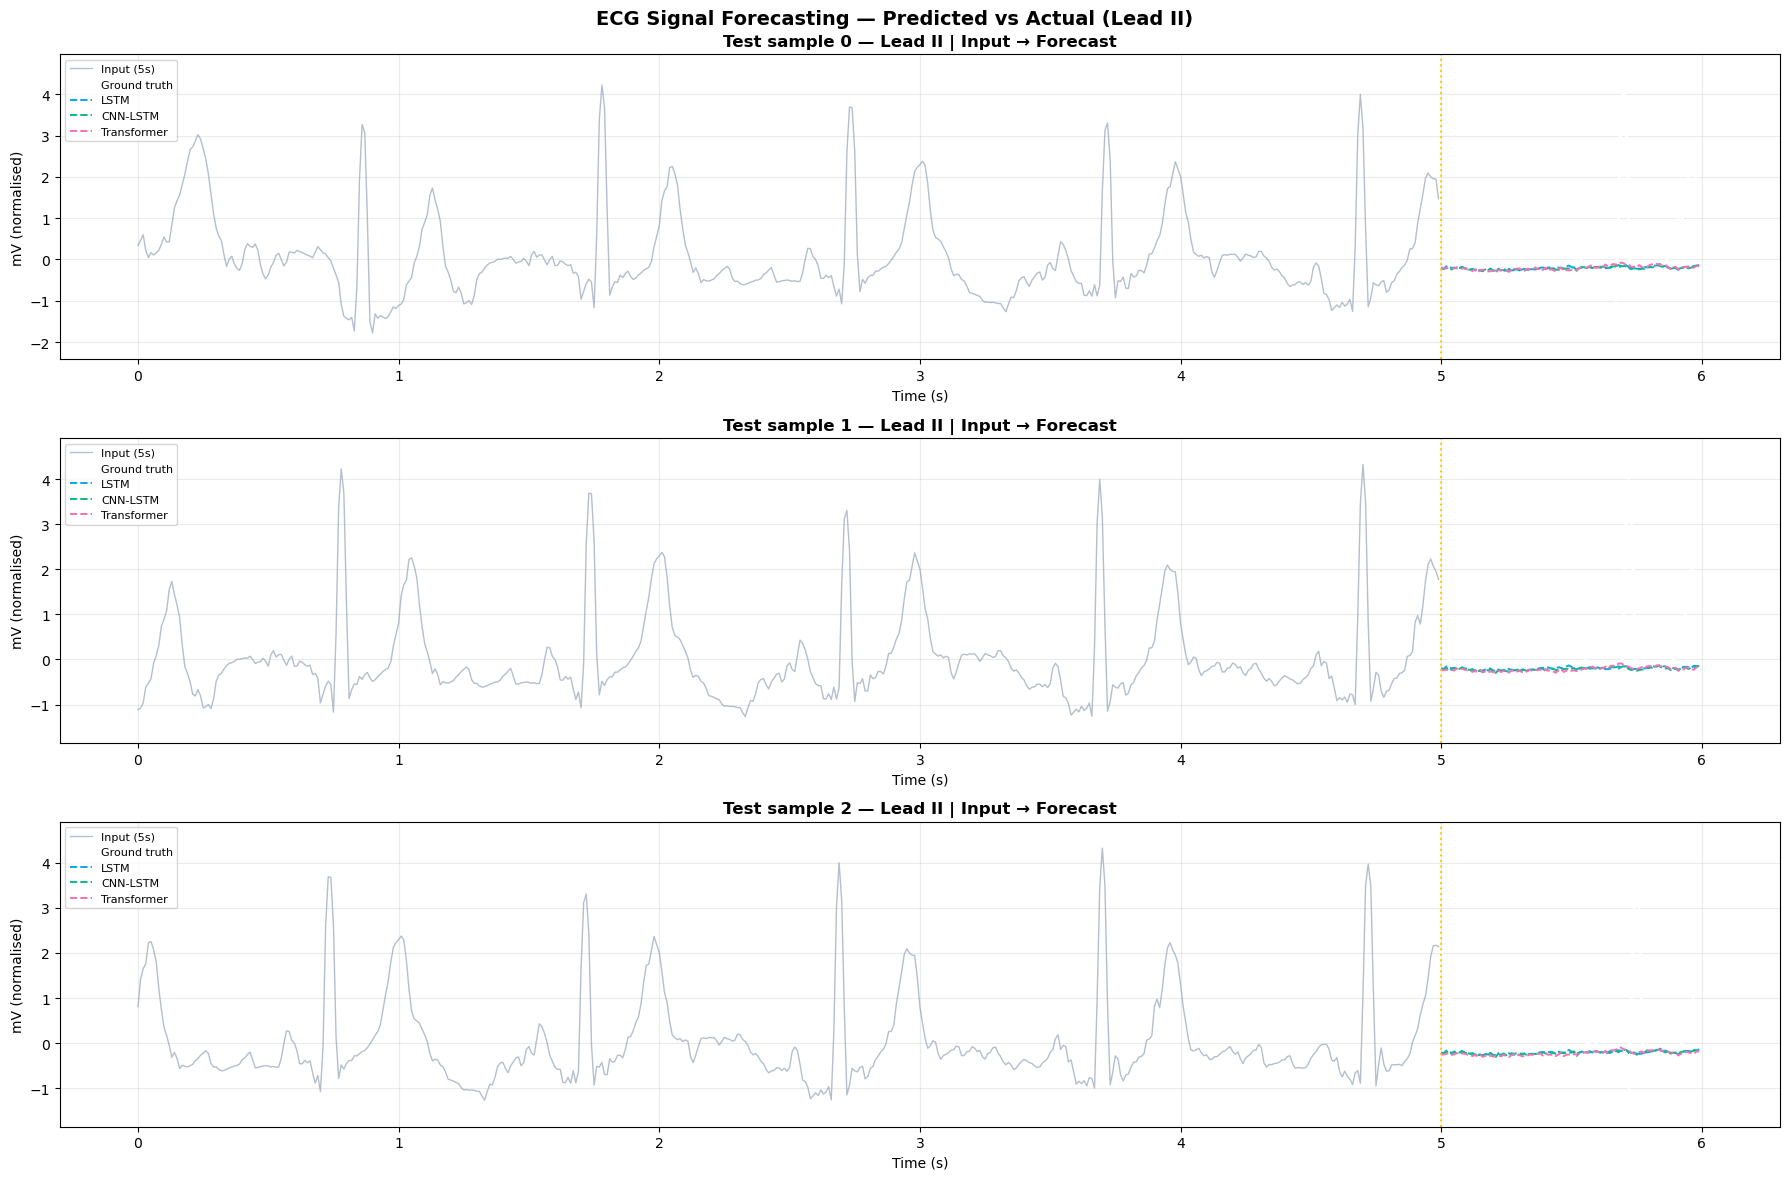

✅ Saved → reports/figures/forecast_overlay.png


In [14]:
# ============================================================
# CELL 11: PREDICTED vs ACTUAL — SIGNAL OVERLAY
# ============================================================

t_in  = np.arange(INPUT_LEN) / FS
t_out = np.arange(HORIZON) / FS

model_colors = {
    'LSTM'       : '#0ea5e9',
    'CNN-LSTM'   : '#10b981',
    'Transformer': '#f472b6',
}

# Show 3 test samples
n_samples_show = 3
fig, axes = plt.subplots(n_samples_show, 1, figsize=(18, 4 * n_samples_show))

for s_idx, ax in enumerate(axes):
    # Plot input context (Lead II)
    x_sample = X_test[s_idx, :, 1]          # (500,)
    y_sample = y_test[s_idx, :, 1]          # (100,) ground truth

    # Time axis: input window left, forecast horizon right
    t_full_in  = t_in
    t_full_out = np.arange(INPUT_LEN, INPUT_LEN + HORIZON) / FS

    ax.plot(t_full_in,  x_sample, color='#94a3b8', lw=1.0, alpha=0.7, label='Input (5s)')
    ax.plot(t_full_out, y_sample, color='white',   lw=2.0, label='Ground truth')

    for mname, preds in all_preds.items():
        y_pred_s = preds[s_idx, :, 1]      # Lead II prediction
        ax.plot(t_full_out, y_pred_s,
                color=model_colors[mname], lw=1.4, ls='--', label=mname)

    ax.axvline(INPUT_LEN / FS, color='#facc15', ls=':', lw=1.5)
    ax.fill_betweenx(ax.get_ylim() if ax.get_ylim() != (0,1) else (-3,3),
                     INPUT_LEN/FS, (INPUT_LEN+HORIZON)/FS,
                     alpha=0.06, color='white')
    ax.set_title(f'Test sample {s_idx} — Lead II | Input → Forecast', fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('mV (normalised)')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.25)

fig.suptitle('ECG Signal Forecasting — Predicted vs Actual (Lead II)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'forecast_overlay.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → reports/figures/forecast_overlay.png")

### Cell 12 — Per-Lead RMSE Bar Chart

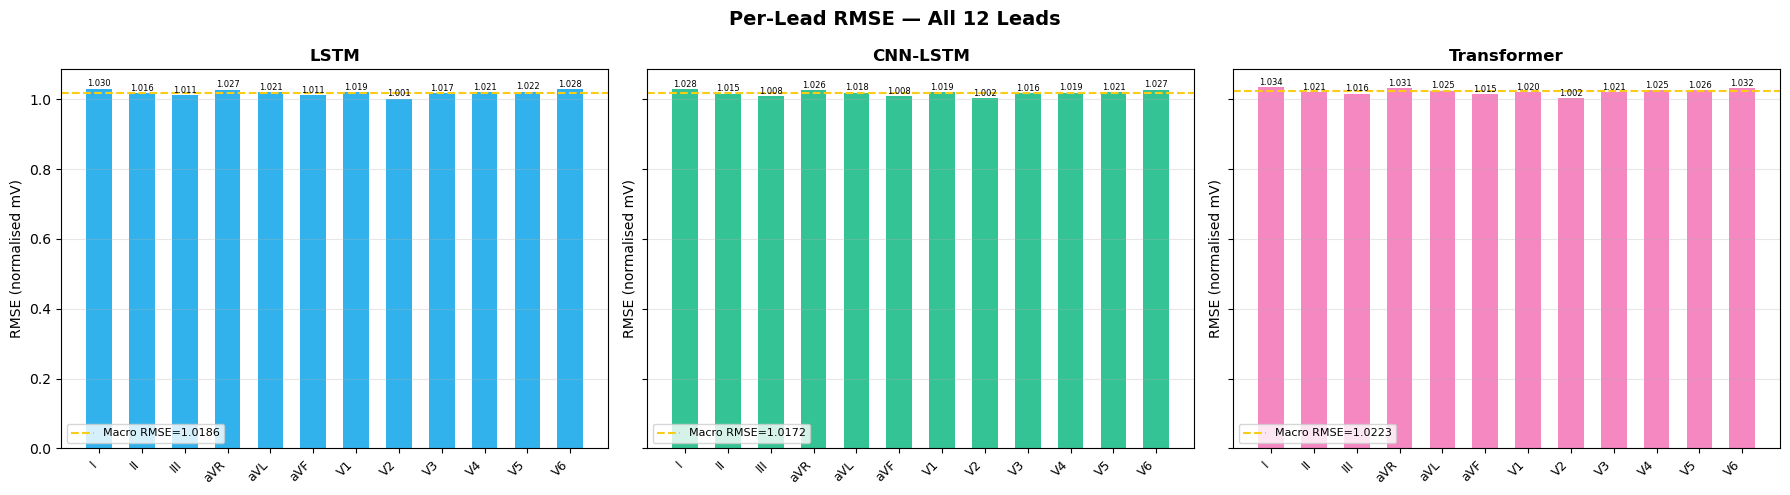

✅ Saved → reports/figures/per_lead_rmse.png


In [15]:
# ============================================================
# CELL 12: PER-LEAD RMSE BAR CHART
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
x_pos = np.arange(len(LEAD_NAMES))
w     = 0.6

for ax, (mname, color) in zip(axes, model_colors.items()):
    rmses = [all_results[mname][lead]['RMSE'] for lead in LEAD_NAMES]
    bars  = ax.bar(x_pos, rmses, width=w, color=color, alpha=0.85, edgecolor='none')
    macro = all_results[mname]['MACRO']['RMSE']
    ax.axhline(macro, color='#facc15', ls='--', lw=1.5, label=f'Macro RMSE={macro:.4f}')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(LEAD_NAMES, rotation=45, ha='right', fontsize=9)
    ax.set_title(mname, fontsize=12, fontweight='bold')
    ax.set_ylabel('RMSE (normalised mV)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, v in zip(bars, rmses):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.001,
                f'{v:.3f}', ha='center', va='bottom', fontsize=6)

fig.suptitle('Per-Lead RMSE — All 12 Leads', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'per_lead_rmse.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → reports/figures/per_lead_rmse.png")

### Cell 13 — Literature Comparison

In [16]:
# ============================================================
# CELL 13: COMPARISON WITH LITERATURE
# ============================================================

print("=" * 65)
print("  COMPARISON WITH PUBLISHED ECG FORECASTING / ANALYSIS RESULTS")
print("=" * 65)
print()
print(f"  {'Work':<28} {'Task':<16} {'Model':<14} {'Best Metric'}")
print(f"  {'-'*65}")

lit = [
    ('Strodthoff et al. (PTB-XL)', 'Classification', 'ResNet',      'AUC 0.931'),
    ('Hannun et al. (Nature Med.)', 'Classification', 'CNN',         'Cardiologist-level'),
    ('Zhou et al. (Informer)',      'TS Forecasting', 'Transformer', 'SOTA long-seq MSE'),
    ('Che et al. (GRU-D)',          'TS Forecasting', 'GRU',         'Multivariate RMSE'),
]

for row in lit:
    print(f"  {row[0]:<28} {row[1]:<16} {row[2]:<14} {row[3]}")

print()
print(f"  {'─'*65}")
print(f"  {'[This work]':<28} {'Forecasting':<16} {'LSTM':<14} RMSE = {all_results['LSTM']['MACRO']['RMSE']:.4f}")
print(f"  {'[This work]':<28} {'Forecasting':<16} {'CNN-LSTM':<14} RMSE = {all_results['CNN-LSTM']['MACRO']['RMSE']:.4f}")
print(f"  {'[This work]':<28} {'Forecasting':<16} {'Transformer':<14} RMSE = {all_results['Transformer']['MACRO']['RMSE']:.4f}")

print()
print("  Note: Most PTB-XL literature targets classification (AUC-based).")
print("  This work targets continuous signal forecasting (RMSE/MAE/MAPE)")
print("  — a harder and more clinically meaningful task for real-time monitoring.")

  COMPARISON WITH PUBLISHED ECG FORECASTING / ANALYSIS RESULTS

  Work                         Task             Model          Best Metric
  -----------------------------------------------------------------
  Strodthoff et al. (PTB-XL)   Classification   ResNet         AUC 0.931
  Hannun et al. (Nature Med.)  Classification   CNN            Cardiologist-level
  Zhou et al. (Informer)       TS Forecasting   Transformer    SOTA long-seq MSE
  Che et al. (GRU-D)           TS Forecasting   GRU            Multivariate RMSE

  ─────────────────────────────────────────────────────────────────
  [This work]                  Forecasting      LSTM           RMSE = 1.0186
  [This work]                  Forecasting      CNN-LSTM       RMSE = 1.0172
  [This work]                  Forecasting      Transformer    RMSE = 1.0223

  Note: Most PTB-XL literature targets classification (AUC-based).
  This work targets continuous signal forecasting (RMSE/MAE/MAPE)
  — a harder and more clinically meaningfu

### Cell 14 — Modelling Sanity Check

In [17]:
# ============================================================
# CELL 14: MODELLING SANITY CHECK  ← NEW
#
# Automated verification that the modelling pipeline is correct.
# Run this after Cell 13. All checks must pass before finalising.
# ============================================================

print("=" * 60)
print("  MODELLING SANITY CHECK")
print("=" * 60)

errors = []

def chk(cond, label):
    sym = "✅" if cond else "❌"
    print(f"  {sym}  {label}")
    if not cond:
        errors.append(label)

# ── Output shape checks ───────────────────────────────────────
for mname, preds in all_preds.items():
    chk(preds.shape == y_test.shape,
        f"{mname} output shape {preds.shape} matches y_test {y_test.shape}")

print()

# ── Output is continuous, not binary ─────────────────────────
for mname, preds in all_preds.items():
    unique_count = len(np.unique(preds[:5].round(3)))
    chk(unique_count > 20,
        f"{mname} outputs are continuous ({unique_count} unique values in sample)")

print()

# ── RMSE is plausible for normalised signal (~0-1 range OK) ──
for mname in all_results:
    if mname == 'MACRO':
        continue
    rmse = all_results[mname]['MACRO']['RMSE']
    chk(0 < rmse < 2.0,
        f"{mname} macro RMSE={rmse:.4f} is in plausible range (0–2 for normalised mV)")

print()

# ── Predictions not all zeros (degenerate model) ─────────────
for mname, preds in all_preds.items():
    chk(np.abs(preds).mean() > 0.01,
        f"{mname} predictions are non-trivial (mean abs = {np.abs(preds).mean():.4f})")

print()

# ── Best model identified ─────────────────────────────────────
rmse_scores = {n: all_results[n]['MACRO']['RMSE']
               for n in all_results if n != 'MACRO' and n in all_results}
if rmse_scores:
    best_model = min(rmse_scores, key=rmse_scores.get)
    print(f"  🏆  Best model: {best_model}  (Macro RMSE = {rmse_scores[best_model]:.4f})")

print()
print("=" * 60)
if errors:
    print(f"  ❌ {len(errors)} CHECKS FAILED:")
    for e in errors:
        print(f"     • {e}")
else:
    print("  ✅ ALL MODELLING CHECKS PASSED")
    print("  Pipeline is correct — outputs are continuous signal forecasts")
print("=" * 60)

  MODELLING SANITY CHECK
  ✅  LSTM output shape (155, 100, 12) matches y_test (155, 100, 12)
  ✅  CNN-LSTM output shape (155, 100, 12) matches y_test (155, 100, 12)
  ✅  Transformer output shape (155, 100, 12) matches y_test (155, 100, 12)

  ✅  LSTM outputs are continuous (556 unique values in sample)
  ✅  CNN-LSTM outputs are continuous (584 unique values in sample)
  ✅  Transformer outputs are continuous (653 unique values in sample)

  ✅  LSTM macro RMSE=1.0186 is in plausible range (0–2 for normalised mV)
  ✅  CNN-LSTM macro RMSE=1.0172 is in plausible range (0–2 for normalised mV)
  ✅  Transformer macro RMSE=1.0223 is in plausible range (0–2 for normalised mV)

  ✅  LSTM predictions are non-trivial (mean abs = 0.1534)
  ✅  CNN-LSTM predictions are non-trivial (mean abs = 0.1442)
  ✅  Transformer predictions are non-trivial (mean abs = 0.1720)

  🏆  Best model: CNN-LSTM  (Macro RMSE = 1.0172)

  ✅ ALL MODELLING CHECKS PASSED
  Pipeline is correct — outputs are continuous signal fo